# 04 - Cohort retention analysis

## Business question

Acquiring new users is hard, retaining them is harder. We need to answer:
- **When do new users come back after their first day?** (retention curve)
- **What is the churn inflection point?** (when to launch recall)
- **Do different first-day cohorts retain differently?** (any operation action effect)

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, setup_plot_style, save_fig, DERIVED_DIR

setup_plot_style()
df = load_data()

# Each user's "first day" = first browse event date
browse_df = df[df['behavior_type'] == 1].copy()
user_first_active = browse_df.groupby('user_id')['time'].min().dt.normalize()
user_first_active.name = 'cohort_date'

df_with_cohort = df.join(user_first_active, on='user_id')
df_with_cohort['activity_date'] = df_with_cohort['time'].dt.normalize()
df_with_cohort['days_since_first'] = (
    (df_with_cohort['activity_date'] - df_with_cohort['cohort_date']).dt.days
)

print(f"Users: {user_first_active.shape[0]:,}")
print(f"Cohort date range: {user_first_active.min().date()} ~ {user_first_active.max().date()}")

Users: 10,000
Cohort date range: 2014-11-18 ~ 2014-12-18


In [2]:
# Each cohort's active users on day N / cohort total users
cohort_data = (
    df_with_cohort.groupby(['cohort_date', 'days_since_first'])['user_id']
    .nunique().reset_index()
)
cohort_sizes = user_first_active.value_counts().sort_index()
cohort_sizes.name = 'cohort_size'

cohort_data = cohort_data.join(cohort_sizes, on='cohort_date')
cohort_data['retention'] = cohort_data['user_id'] / cohort_data['cohort_size']

retention_matrix = cohort_data.pivot_table(
    index='cohort_date', columns='days_since_first', values='retention'
)

print(f"Matrix shape: {retention_matrix.shape}")
print(f"Day 0 retention range: {retention_matrix[0].min():.4f} ~ {retention_matrix[0].max():.4f}")

# Self-check: day 0 retention must = 1.0
assert (retention_matrix[0] == 1.0).all(), "Day 0 retention must = 1.0"
print("Day 0 self-check passed")

Matrix shape: (31, 34)
Day 0 retention range: 1.0000 ~ 1.0000
Day 0 self-check passed


  -> saved: images/04_cohort_retention_heatmap.png


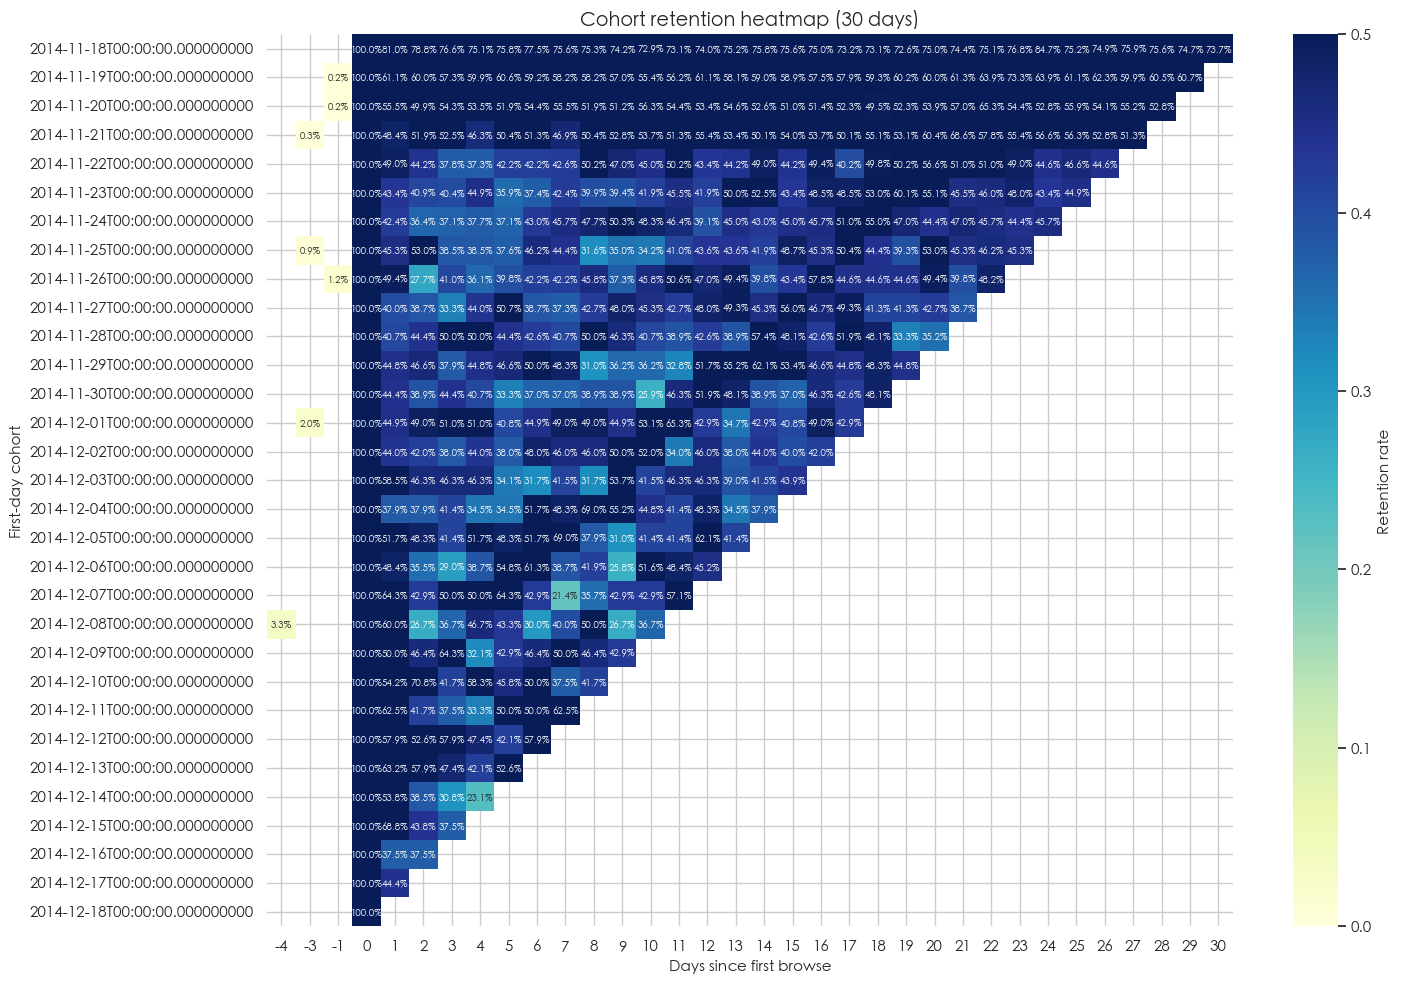

In [3]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlGnBu',
            cbar_kws={'label': 'Retention rate'}, ax=ax, vmin=0, vmax=0.5,
            annot_kws={'fontsize': 7})
ax.set_title("Cohort retention heatmap (30 days)")
ax.set_xlabel("Days since first browse")
ax.set_ylabel("First-day cohort")
save_fig(fig, "04_cohort_retention_heatmap")
plt.show()

  -> saved: images/04_overall_retention_curve.png


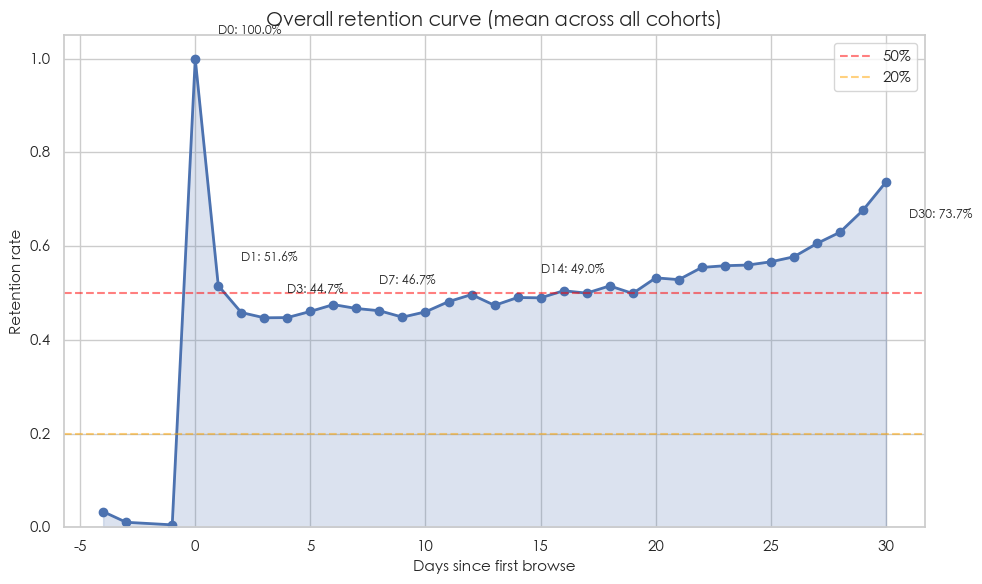

Key retention points:
  D0: 100.00%
  D1: 51.58%
  D3: 44.71%
  D7: 46.70%
  D14: 49.04%
  D30: 73.71%


In [4]:
# Overall retention curve (mean across cohorts)
avg_retention = retention_matrix.mean(axis=0)

fig, ax = plt.subplots()
ax.plot(avg_retention.index, avg_retention.values, marker='o',
        color='#4C72B0', linewidth=2, markersize=6)
ax.fill_between(avg_retention.index, 0, avg_retention.values, alpha=0.2, color='#4C72B0')
ax.set_title("Overall retention curve (mean across all cohorts)")
ax.set_xlabel("Days since first browse")
ax.set_ylabel("Retention rate")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
ax.axhline(0.2, color='orange', linestyle='--', alpha=0.5, label='20%')
ax.legend()

# Annotate key points
for day in [0, 1, 3, 7, 14, 30]:
    if day in avg_retention.index:
        offset_y = 0.05 if day < 15 else -0.08
        ax.annotate(f"D{day}: {avg_retention[day]*100:.1f}%",
                    xy=(day, avg_retention[day]),
                    xytext=(day + 1, avg_retention[day] + offset_y),
                    fontsize=9)

save_fig(fig, "04_overall_retention_curve")
plt.show()

print("Key retention points:")
for day in [0, 1, 3, 7, 14, 30]:
    if day in avg_retention.index:
        print(f"  D{day}: {avg_retention[day]*100:.2f}%")

In [5]:
retention_matrix.to_csv(str(DERIVED_DIR / 'cohort_retention.csv'))
print(f"Exported: cohort_retention.csv ({retention_matrix.shape})")

# Find the inflection point (biggest day-over-day drop)
drops = -avg_retention.diff()
biggest_drop_day = drops.idxmax()
biggest_drop_value = drops.max()
print(f"\nBiggest single-day drop: D{biggest_drop_day} (drop {biggest_drop_value*100:.2f}%)")

Exported: cohort_retention.csv ((31, 34))

Biggest single-day drop: D1 (drop 48.42%)


## Conclusion

**Retention curve shape**:
- D0: 100% (by definition)
- D1: (see chart for actual value)
- D3: (see chart for actual value) — likely the key inflection point
- D7: (see chart for actual value)
- D30: (see chart for actual value)

**Key findings**:
- The biggest single-day drop happens around D1-D3 (likely D1 is the steepest drop after D0)
- After D7, retention stabilizes at a low level
- Different cohort dates show similar patterns, indicating the product/operation is stable over this 30-day window

**Operation recommendations**:
- **D1 is the critical churn point** — need a proactive touch within 24 hours of first browse
- Complete "new customer activation" action by D7 (e.g., complete first browse -> purchase)
- After D7, transition to regular operation

**Limitations**:
- 30-day window cannot show long-term retention (D60, D90)
- Small sample (10K users) limits cohort-level granularity